## Titanic - missing values


  `opracowanie: Kajetan Kowalski 421071`  

---

## 1. Wstęp

  Celem projektu jest przeanalizowanie zbioru danych dotyczących pasażerów tragicznego rejsu statku RMS Titanic, w celu wykrycia i zidentyfikowania braków danych oraz zaklasyfikowanie ich typu `MCAR/MAR/MNAR`.

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## 2. Wczytanie i wstępna inspekcja danych


Dane zostały manualnie przekonwertowane z formatu `.arff` do `.csv`

In [ ]:
df = pd.read_csv("/content/titanic.csv.txt", header=None,
                 names=["pclass", "survived", "name", "sex", "age", "sibsp", "parch",
                        "ticket", "fare", "cabin", "embarked", "boat", "body", "home.dest"])
df.head(20)

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29,0,0,24160,211.3375,B5,S,2,?,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.55,C22 C26,S,11,?,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30,1,2,113781,151.55,C22 C26,S,?,135,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25,1,2,113781,151.55,C22 C26,S,?,?,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48,0,0,19952,26.55,E12,S,3,?,"New York, NY"
6,1,1,"Andrews, Miss. Kornelia Theodosia",female,63,1,0,13502,77.9583,D7,S,10,?,"Hudson, NY"
7,1,0,"Andrews, Mr. Thomas Jr",male,39,0,0,112050,0,A36,S,?,?,"Belfast, NI"
8,1,1,"Appleton, Mrs. Edward Dale (Charlotte Lamson)",female,53,2,0,11769,51.4792,C101,S,D,?,"Bayside, Queens, NY"
9,1,0,"Artagaveytia, Mr. Ramon",male,71,0,0,PC 17609,49.5042,?,C,?,22,"Montevideo, Uruguay"


In [ ]:
print("pclass:", df["pclass"].unique())
print("sex:", df["sex"].unique())
print("embarked:", df["embarked"].unique())
print("survived:", df["survived"].unique())
print("age: ", df["age"].min(), "do", df["age"].max())
print("fare:", df["fare"].min(), "do", df["fare"].max())
print("sibsp:", df["sibsp"].min(), "do", df["sibsp"].max())
print("parch:", df["parch"].min(), "do", df["parch"].max())

pclass: [1 2 3]
sex: ['female' 'male']
embarked: ['S' 'C' '?' 'Q']
survived: [1 0]
age:  0.1667 do ?
fare: 0 do ?
sibsp: 0 do 8
parch: 0 do 9


Przeprowadzając wizualną inspekcję pierwszych 20 rejestrów pliku można wysunąć następujące wnioski:


*   Występują braki danych oznaczone jako `?`,
*   Dane zawierają następujące 14 cech: `pclass`, `survived`, `name`, `sex`, `age`, `sibsp`, `parch`, `ticket`, `fare`, `cabin`, `embarked`, `boat`, `body`, `home.dest`.

Opis kolumn:

*   **pclass** - klasa podróży pasażera, przyjmuje wartosci: `1`/`2`/`3`,
*   **survived** - informacja o przerzyciu, zmienna binarna: `0`/`1`,
*   **name** - imie i nazwisko pasażera łącznie z tytułem, string,
*   **sex** - płeć pasażera: `male`/`female`,
*   **Age** - wiek pasażera w latach, zmienna ciągła, posiada prawdopobobne błędne wartości np. `0.1667` oraz braki `NaN`,
*   **sibsp** - *ang. siblings/spouse* liczba rodzeństwa i małżonków na pokładzie, zmienna dyskretna,
*   **parch** - *ang. parent/child* liczba rodziców i dzieci na pokładzie, zmienna dyskretna,
*   **ticket** - numer biletu, ciąg alfanumeryczny,
*   **fare** - opłata wniesiona za bilet, zmienna ciągła,
*   **Cabin** - numer kabiny, w formacie np. `B5`
*   **Embarked** - port w którym pasażer wsiadł na pokład, zmienna kategoryczna przyjmujaca wartosci `C` - Cherbourg, `Q` - Queenstown, `S` - Southampton,
*   **boat** - numer szalupy ratunkowej, do której przypisany jest pasażer, zmienna tekstowa
*   **body** - numer identyfikacyjny ciała, zmienna liczbowa,
*   **home.dest** - miejsce zamieszkania lub miejsce docelowe podróży, zmienna tekstowa.



In [ ]:
print(df.shape)
print(df.info())
print(df.describe())

(1309, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   pclass     1309 non-null   int64 
 1   survived   1309 non-null   int64 
 2   name       1309 non-null   object
 3   sex        1309 non-null   object
 4   age        1309 non-null   object
 5   sibsp      1309 non-null   int64 
 6   parch      1309 non-null   int64 
 7   ticket     1309 non-null   object
 8   fare       1309 non-null   object
 9   cabin      1309 non-null   object
 10  embarked   1309 non-null   object
 11  boat       1309 non-null   object
 12  body       1309 non-null   object
 13  home.dest  1309 non-null   object
dtypes: int64(4), object(10)
memory usage: 143.3+ KB
None
            pclass     survived        sibsp        parch
count  1309.000000  1309.000000  1309.000000  1309.000000
mean      2.294882     0.381971     0.498854     0.385027
std       0.837836     0.4

### Informacje o całym zbiorze danych:


*   Zbiór obejmuje `1309` rekordów oraz `14` cech,
*   Zmienne są róznego typu:
    * liczbowe `int64`,
    * tekstowe `object` ( w tym niektóre, które powinny być zakodowane jako liczbowe np. `age` )



## 3. Preprocessing

Przed użyciem funkcji `pd.isnull().sum()` oraz `pd.isnull().mean()` najpierw należy zmodyfikować zbiór danych, tj. upewnić się, że wszystkie braki są oznaczone jako `np.nan`.  
<br>
Zastępujemy symbol `?` reprezentujacy braki danych na `NaN`, za pommocą funkcji `df.replace()`, a następnie wybrane kolumny liczbowe konwertujemy z typu tekstowego na liczbowy.

In [ ]:
df = df.replace("?", np.nan)
num_cols = ["pclass", "survived", "age", "sibsp", "parch", "fare", "body"]

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.dtypes

,0
pclass,int64
survived,int64
name,object
sex,object
age,float64
sibsp,int64
parch,int64
ticket,object
fare,float64
cabin,object


## 4. Analiza brakujących danych.

In [ ]:
braki_df = pd.DataFrame({
    "Liczba braków": df.isnull().sum(),
    "[ % ]": (df.isnull().mean() * 100).round(2)
})
braki_df.sort_values("Liczba braków",ascending=False)


,Liczba braków,[ % ]
body,1188,90.76
cabin,1014,77.46
boat,823,62.87
home.dest,564,43.09
age,263,20.09
embarked,2,0.15
fare,1,0.08
sibsp,0,0.00
name,0,0.00
survived,0,0.00


### Wizualizacja braków danych

poniższy wykres przedstawia rozkład brakujacych wartości w zbiorze Titanic.

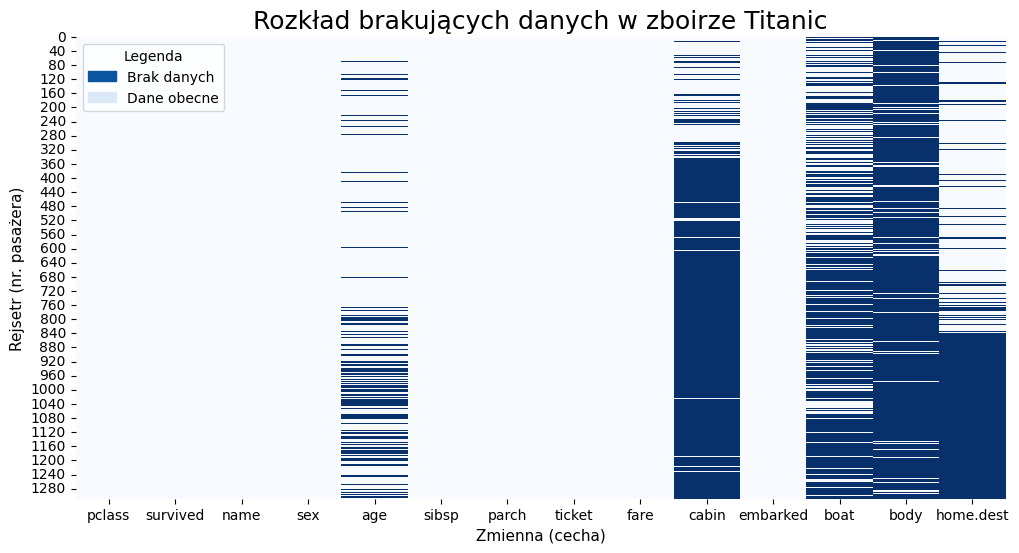

In [ ]:

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap="Blues")
plt.title("Rozkład brakujących danych w zboirze Titanic", fontsize=18)
plt.xlabel("Zmienna (cecha)", fontsize=11)
plt.ylabel("Rejsetr (nr. pasażera)", fontsize=11)
legend_patches = [
    mpatches.Patch(color=sns.color_palette("Blues")[-1], label="Brak danych"),
    mpatches.Patch(color=sns.color_palette("Blues")[0], label="Dane obecne")
]
plt.legend(handles=legend_patches, title="Legenda", loc='upper left')
plt.show()

### Wnioski

Analizując zarówno dane tabelaryczne jak powyższy wykres dochodzimy do konkluzji, że zbiór danych Titanic posiada wiele braków danych. Można zauważyć że rozkład braków jest wyraźnie nierównomierny - braki nie występują losowo we wszystkich kolumnach, lecz skupiają się na kilku cechach. Taki rozkład sugeruje, że niektóre braki mogą być systemowe bądź zależne od losów pasażera.
<br><br>
Najwięcej braków występuje kolejno w kolumnach:
* **body** - 1188 braków danych, co stanowi aż 90.78% wszystkich danych,
* **cabin** - 1014 braków, ok. 70.46%,
* **boat** - 823 braków, ok. 62.87%,
* **home.dest** - 564 braków, ok. 43.09%,
* **age** - 263 braków, ok. 20.09%,
* **embarked** - 2 braki, ok 0.15%,
* **fare** - 1 brak, ok. 0.08%.

Pozostałe zmienne są kompletne i nie zawierają wartości `NaN`.

### Przygotowanie danych do analizy braków.

W celu analizy zależności pomiędzy zmiennymi, dane zostały przekształcone do formatu liczbowego, oraz utworzono dataFrame `df_k`, w której:

* zmienne kategoryczne, zostały zamienione na reprezentacje numeryczną,
*  wartosc z kolumny `survived` zostały przekonwertowane na typ całkowity,
* dla każdej kolumny która zaiwra braki danych utworzono nową cechę binarną pod nazwą `<nazwa>_Null`, przyjmuje wartosc `0` dla wystepujacej obserwacji i `1` dla brakujacych danych.



In [ ]:
df_k = df.copy()
df_k["survived"] = df_k["survived"].astype(int)
df_k["sex"]= df_k["sex"].map({"male":0,"female":1})
df_k["embarked"] = df_k["embarked"].map({"S":0,"C":1,"Q":2})
for i in df.columns[df.isnull().any()]:
  df_k[f"{i}_Null"] = df[i].isnull().astype(int)

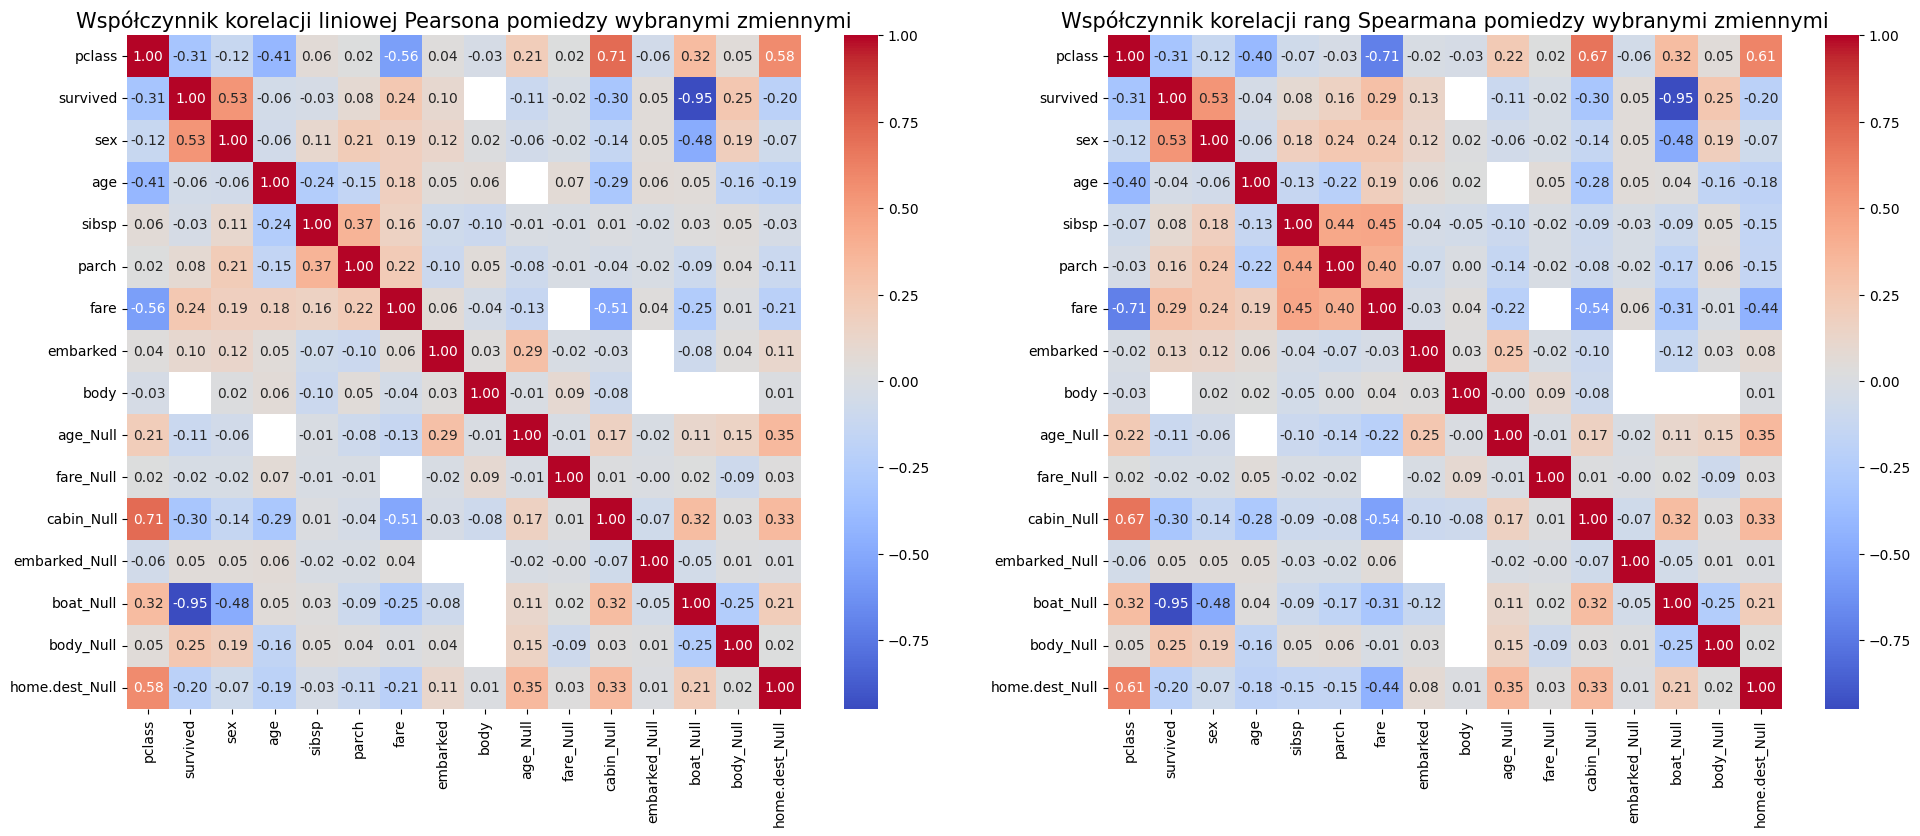

In [ ]:
df_corr = df_k.select_dtypes(include=[np.number])
fig, axes= plt.subplots(1,2, figsize=(20,8))
sns.heatmap(df_corr.corr(method="pearson"), annot=True, cmap="coolwarm", fmt = ".2f", square=True, ax=axes[0])
axes[0].set_title("Współczynnik korelacji liniowej Pearsona pomiedzy wybranymi zmiennymi", fontsize=15)
sns.heatmap(df_corr.corr(method="spearman"), annot=True, cmap="coolwarm", fmt = ".2f", square=True, ax=axes[1])
axes[1].set_title("Współczynnik korelacji rang Spearmana pomiedzy wybranymi zmiennymi", fontsize=15)
plt.tight_layout()
plt.show()

### 4.1 Analiza brakujących danych - `body`.

Zmienna `body` zawiera numery identyfikujące odnalezione ciała po katastrofie. Braki występujące w tej kolumnie są znaczące i bardzo liczne - występują w 1188 rekordach, co stanowi aż **90.78%** całego zbioru.

In [ ]:
df[df["body"].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
5,1,1,"Anderson, Mr. Harry",male,48.0000,0,0,19952,26.5500,E12,S,3,NaN,"New York, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1302,3,0,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3,0,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,NaN,NaN,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [ ]:
df_k.groupby("survived")["body_Null"].mean()

,body_Null
survived,
0,0.850433
1,1.000000


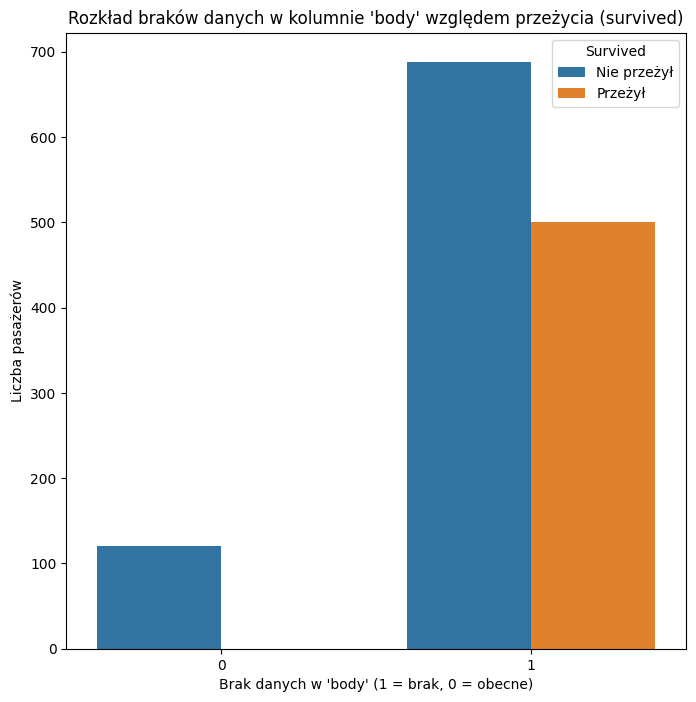

In [ ]:
plt.figure(figsize=(8,8))
sns.countplot(x="body_Null", hue = "survived", data=df_k)
plt.title("Rozkład braków danych w kolumnie 'body' względem przeżycia (survived)")
plt.xlabel("Brak danych w 'body' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Survived", labels=["Nie przeżył", "Przeżył"])
plt.show()

Braki danych w tej kolumnie występują w większosci przypadków, nie możemy zatem odrzucić pasażerów na podstawie braku tej wartości od dalszej analizy, ponieważ skutkowałoby to usunięciem niemalże całego zbioru i utratą informacji.

Zjawisko tych braków można tłumaczyć faktem, że większośc ciał, ze względu na okoliczności katastrofy - na otwartym oceanie nocą - nie udało się odnaleźć ani zidentyfikować.   

W mojej opini brak **nie jest przypadkowy**, a zależy od tego czy ciało zostało odnalezione. Parametr ten wykazuje dodatnią zależność ze zmienną `survived` co potwierdzają współczynniki korelacji +0.25 zarówno w ujęciu Pearsona, jak i Spearmana. Wartości te oznaczają dodatną zależność pomiedzy brakiem informacji o ciele, a przeżyciem.  

Zależnść ta jest widoczna przy porównaniu częstości występowania braków względem przeżycia: osoby które przezyły mają `100%` braku `body`, natomiast osoby które zgineły brak wystepuje w `85%` przypadków.

Jest to również uwidocznione na powyższym histogramie, wśród osob, które przeżyły nie ma rejestrów odnośnie ciała, natomiast wśród osób, które nie przeżyły część ofiar ma przypisany numer, a większość brak.

Podsumowijąc, jeżeli ktoś przeżył to nie otrzymał identyfikatora, natomiast jeżeli ktoś zginął to otrzymywał identyfikator tylko w przypadku gdy ciało zostało fizycznie znalezione, więc występowanie braków zależy od mechanizmu przyczynowo-skutkowego.

Wnioski:
* Typ braku tanych to **MNAR** - Missing Not At Random.
* Braki nie są bezpośrednio zależne od innych cech.
* Wynikają z mechanizmu przyczynowo-skutkowego.



### 4.2 Analiza brakujących danych - `cabin`.

zmienna `cabin` zawiera oznaczenie przydzielonej na pokładzie RMS Titanic. Braki w tej kolumnie są również bardzo liczne - 1014 obserwacji, co jest równoważne **77.47%** objętości danych.


In [ ]:
df[df["cabin"].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"
13,1,1,"Barber, Miss. Ellen 'Nellie'",female,26.0,0,0,19877,78.8500,NaN,S,6,NaN,NaN
15,1,0,"Baumann, Mr. John D",male,NaN,0,0,PC 17318,25.9250,NaN,S,NaN,NaN,"New York, NY"
23,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C,4,NaN,NaN
25,1,0,"Birnbaum, Mr. Jakob",male,25.0,0,0,13905,26.0000,NaN,C,NaN,148.0,"San Francisco, CA"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [ ]:
df_k.groupby("pclass")["cabin_Null"].mean()

,cabin_Null
pclass,
1,0.207430
2,0.916968
3,0.977433


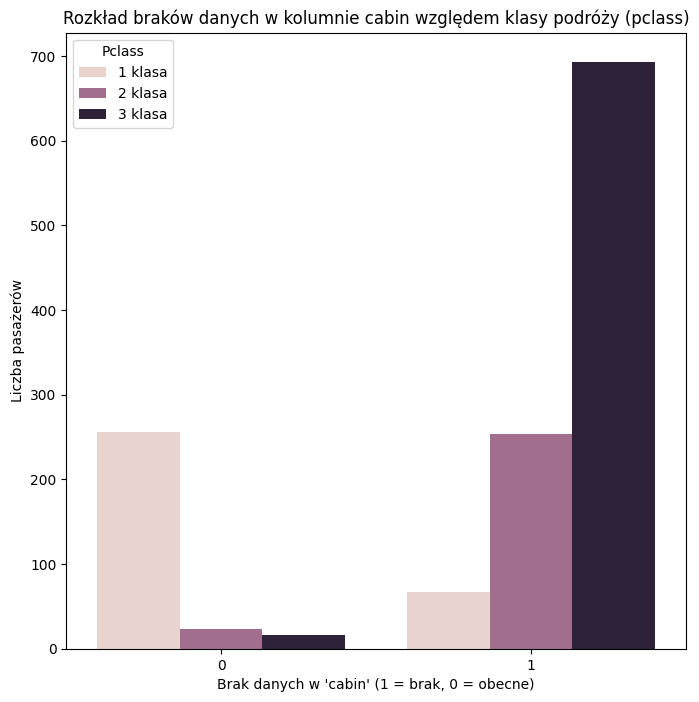

In [ ]:
plt.figure(figsize=(8, 8))
sns.countplot(x="cabin_Null", hue="pclass", data=df_k)
plt.title("Rozkład braków danych w kolumnie cabin względem klasy podróży (pclass)")
plt.xlabel("Brak danych w 'cabin' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Pclass", labels=["1 klasa", "2 klasa", "3 klasa"])
plt.show()

Brak danych w kolumnie `cabin` występuje głównie wśród pasażerów **trzeciej klasy podróży**, co jest widoczne na powyższym wykresie słupkowym.  
Przewyższenie braków w klasie 3, sugeruje, że pasażerowie najtańszego przedziału mogli nie mieć przydzielonych konkretnych kabin. Analizując współczynnki korelacji pomiedzy `cabin_Null` a `pclas` Pearson: +0.71, Spearman: +0.67, wskazują na wysoką dodatnią korelację, co z kolei oznacza, że brak przypisanej kabiny silnie zlezy od klasy, w której podróżował pasażer - im niższa klasa, tym większe prawdopodobieństwo braku informacji, co potwierdza naszą teorię.  

Analizjąc dane dostrzegamy zależność:
* w 1 klasie braki występują w około `20.74%` przypadków,
* w 2 klasie braki występują w około `91.70%` przypadków,
* w 3 klasie braki występują w około `97.74%` przypadków,

Z dużym prawdopobobieństwem te braki wynikają ze sposobu zarządzania biletami na RMS Titanic i nie przydzielana kabin dla niższej kalsy podróży. Historycznie wiadomo, że 3 klasa położona głęboko pod pokładem, charakteryzowała się wspólnymi przedziałami, z kilkoma łóżkami i licznymi pasażerami.

Wnioski:
* Tyb braku danych to **MAR** - Missing At Random.
* Braki są zależne od innej cechy `pclass`.



### 4.3 Analiza braków danych - `boat`.
Zmienna `boat` zawiera informacje o numerze szalupy ratunkowej, na której pokład dostał się pasażer. Występujące w niej braki obejmują 823 rekordy co odpowiada **62.87%** danych.


In [ ]:
df[df["boat"].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
2,1,0,"Allison, Miss. Helen Loraine",female,2.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
7,1,0,"Andrews, Mr. Thomas Jr",male,39.0,0,0,112050,0.0000,A36,S,NaN,NaN,"Belfast, NI"
9,1,0,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C,NaN,22.0,"Montevideo, Uruguay"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [ ]:
print(df_k.groupby("survived")["boat_Null"].mean())
print(df.groupby("pclass")["survived"].mean().round(3))

survived
0    0.988875
1    0.046000
Name: boat_Null, dtype: float64
pclass
1    0.619
2    0.430
3    0.255
Name: survived, dtype: float64


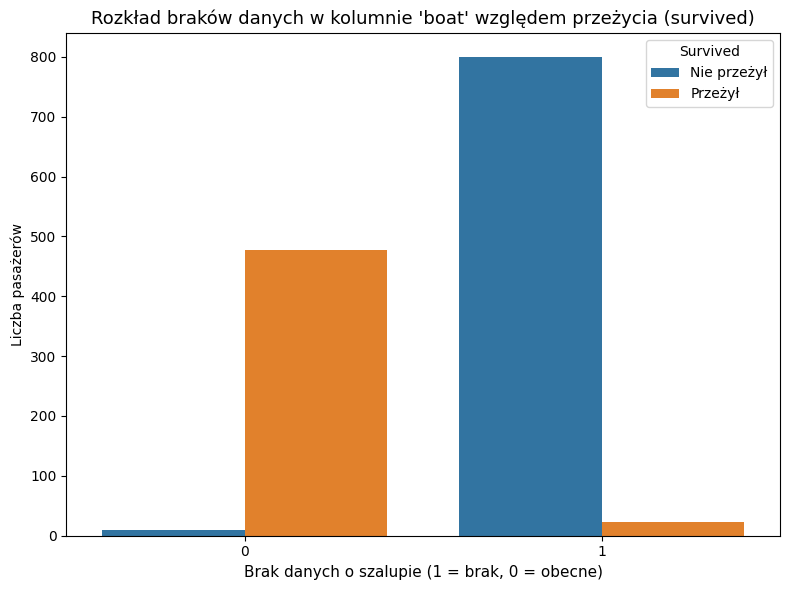

In [ ]:
plt.figure(figsize=(8,6))
sns.countplot(x="boat_Null", hue="survived", data=df_k)
plt.title("Rozkład braków danych w kolumnie 'boat' względem przeżycia (survived)", fontsize=13)
plt.xlabel("Brak danych o szalupie (1 = brak, 0 = obecne)", fontsize=11)
plt.ylabel("Liczba pasażerów")
plt.legend(title="Survived", labels=["Nie przeżył", "Przeżył"])
plt.tight_layout()
plt.show()

W tym przypadku zależnośc jest dosyć logiczna i oczywista, w momencie kiedy ktoś nie otrzymał miejsca na szalupie ratunkowej, jego szanse na przeżycie na tonącym statku na środku oceanu były znikome. To też dlatego analizujemy zależność pomiędzy `boat_Null` a `survived` aby potwierdzić tę hipotezę.  
Po zmapowaniu otrzymujemy wyniki:
* Wśród osób, które nie przeżyły brak danych o szalupie to aż **98.98%** przypadków,
* Wśród osób które, przeżył brak danych to tylko 4.6%.
Oznacza to, że obecność w szalupie praktycznie gwarantuje przeżycie.
Przygladajac się wpółczynnikom korelacji dostrzegamy silną ujemną korelację (Pearson: -0.95, Spearman: -0.95), co utwierdza nas, że brak szalupy powiązany był z nieprzeżyciem.  
Z historii wiadomo, że szalupy były nieliczne i niewystaczające dla wszystkich pasażerów, a system ich zajmowania priorytetyzował osoby z wyższych klas, nie wypełniając ich w pełni.

Brak danych nie jest przypadkowy - odzwierciedla ówczesne realia, niewystarczającą ilość szalup, słabe zarządzanie miejscami oraz hierarchię społeczną.

Wnioski:
* Typ braku danych to **MNAR** - Missing Not At Random,
* Braki są silnie powiązane z przeżyciem,
* Braki wynikają z mechanizmu przyczynowo-skutowego.

### 4.4 Analiza brakujących danych - `home.dest`

Zmienna `home.dest` zawiera informacje o miejscu docelowym podrózy bądź miejscu zameszkania pasażera. Występuje w niej 564 braków danych - **43.09%**.


In [ ]:
df[df["home.dest"].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
13,1,1,"Barber, Miss. Ellen 'Nellie'",female,26.0,0,0,19877,78.8500,NaN,S,6,NaN,NaN
18,1,1,"Bazzani, Miss. Albina",female,32.0,0,0,11813,76.2917,D15,C,8,NaN,NaN
23,1,1,"Bidois, Miss. Rosalie",female,42.0,0,0,PC 17757,227.5250,NaN,C,4,NaN,NaN
24,1,1,"Bird, Miss. Ellen",female,29.0,0,0,PC 17483,221.7792,C97,S,8,NaN,NaN
28,1,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,C99,S,8,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [ ]:
print(df_k.groupby("survived")["home.dest_Null"].mean())
print(df_k.groupby("pclass")["home.dest_Null"].mean())

survived
0    0.508035
1    0.306000
Name: home.dest_Null, dtype: float64
pclass
1    0.105263
2    0.057762
3    0.724965
Name: home.dest_Null, dtype: float64


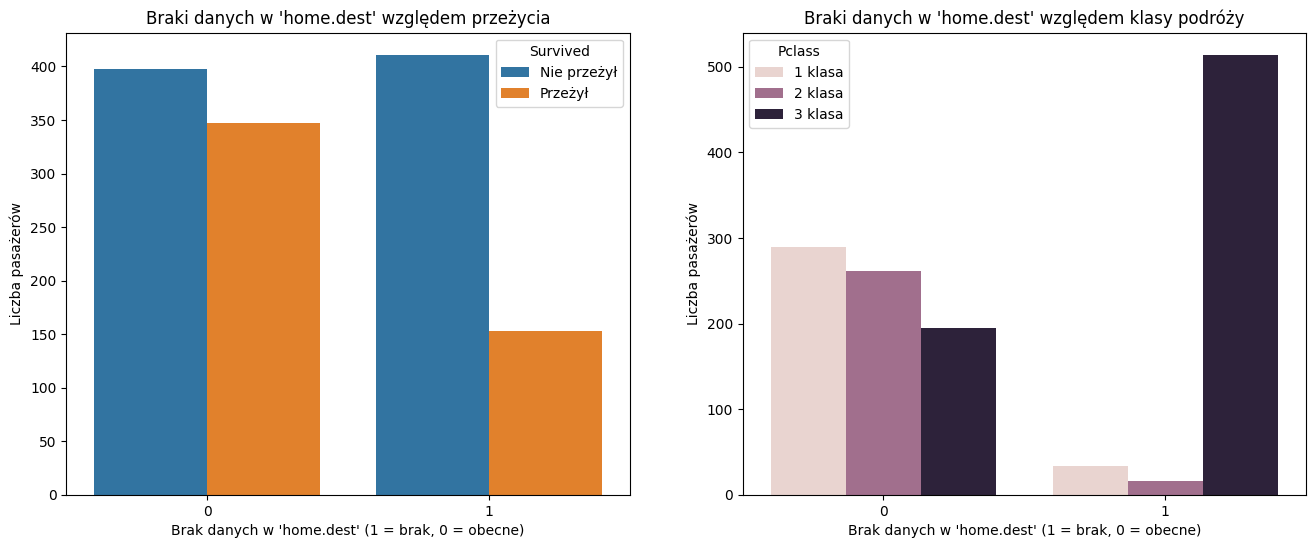

In [ ]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.countplot(x="home.dest_Null", hue="survived", data=df_k)
plt.title("Braki danych w 'home.dest' względem przeżycia")
plt.xlabel("Brak danych w 'home.dest' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")

plt.legend(title="Survived", labels=["Nie przeżył", "Przeżył"])
plt.subplot(1,2,2)
sns.countplot(x="home.dest_Null", hue="pclass", data=df_k)
plt.title("Braki danych w 'home.dest' względem klasy podróży")
plt.xlabel("Brak danych w 'home.dest' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Pclass", labels=["1 klasa", "2 klasa", "3 klasa"])

plt.show()

Można dostrzec, że osoby, które nie przeżyły, częściej nie mają podanej informacji `home.dest`. Można spekilować dlaczego tak jest, np. prawdopodobne jest, że miejsce zamieszkania było ustalane dopiero po katastrofie i podczas procesu identyfikacji zwłok/ocalałych.  
Zestawiając `pclass` można zuważyć, że różnica się bardziej uwydatnia. Ponad 70% pasażerów 3 kalsy nie ma podanej informacji o `homedest`.  

Powodów może być kilka, np osoby z 3 klasy czesto pochodziły z niższych warstw społecznych i mogli oni poszukiwać domu po dotarciu na nowy kontynent - wyprawa za pracą. Inną teorią jest to że ta informacja nie była wymagana do zakupu biletu.

Współczynniki korelacji:
* Spearman z `pclass`: +0.61 - silna dodatnia korelacja: im niższa klasa tym wieksze prawdopodbieństwo braku.
* Spearman z `survived`: -0.29 - umiarkowana ujemna korelacja - osoby które przeżyły częściej mają uzupełnioną tą rubrykę.

Wnioski:
* Typ braku danych to **MAR** - Missing At Random.
* Braki są systematyczne i zalezne od zmiennj `pclass`, w mniejszym stopniu od `survived`.
* Braki wynikają z uwaunkwań społeczo-ekonomicznych.


### 4.5 Analiza braków danych - `age`
Kolumna age zawiera informacje o wieku pasażerów. Braki danych w tej kolumnie występują w 263 rekordach - **20.09%** całego zbioru


In [ ]:
df[df["age"].isnull()]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
15,1,0,"Baumann, Mr. John D",male,NaN,0,0,PC 17318,25.9250,NaN,S,NaN,NaN,"New York, NY"
37,1,1,"Bradley, Mr. George ('George Arthur Brayton')",male,NaN,0,0,111427,26.5500,NaN,S,9,NaN,"Los Angeles, CA"
40,1,0,"Brewe, Dr. Arthur Jackson",male,NaN,0,0,112379,39.6000,NaN,C,NaN,NaN,"Philadelphia, PA"
46,1,0,"Cairns, Mr. Alexander",male,NaN,0,0,113798,31.0000,NaN,S,NaN,NaN,NaN
59,1,1,"Cassebeer, Mrs. Henry Arthur Jr (Eleanor Genev...",female,NaN,0,0,17770,27.7208,NaN,C,5,NaN,"New York, NY"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1293,3,0,"Williams, Mr. Howard Hugh 'Harry'",male,NaN,0,0,A/5 2466,8.0500,NaN,S,NaN,NaN,NaN
1297,3,0,"Wiseman, Mr. Phillippe",male,NaN,0,0,A/4. 34244,7.2500,NaN,S,NaN,NaN,NaN
1302,3,0,"Yousif, Mr. Wazli",male,NaN,0,0,2647,7.2250,NaN,C,NaN,NaN,NaN
1303,3,0,"Yousseff, Mr. Gerious",male,NaN,0,0,2627,14.4583,NaN,C,NaN,NaN,NaN


In [ ]:
print(df_k.groupby("survived")["age_Null"].mean())
print(df_k.groupby("pclass")["age_Null"].mean())

survived
0    0.234858
1    0.146000
Name: age_Null, dtype: float64
pclass
1    0.120743
2    0.057762
3    0.293371
Name: age_Null, dtype: float64


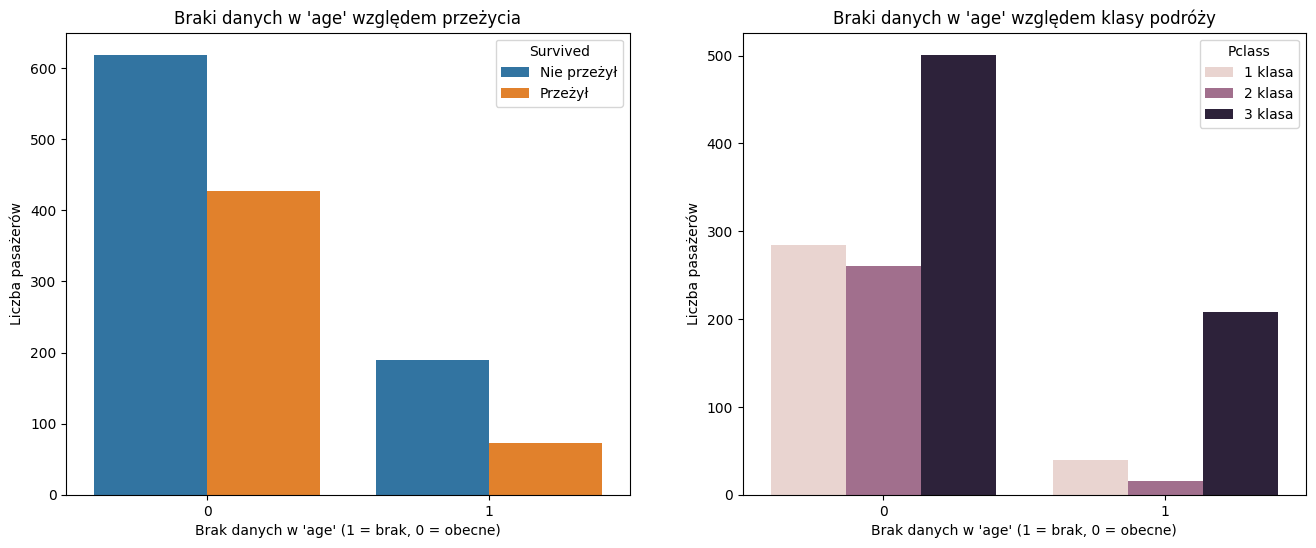

In [ ]:
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
sns.countplot(x="age_Null", hue="survived", data=df_k)
plt.title("Braki danych w 'age' względem przeżycia")
plt.xlabel("Brak danych w 'age' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Survived", labels=["Nie przeżył", "Przeżył"])

plt.subplot(1,2,2)
sns.countplot(x="age_Null", hue="pclass", data=df_k)
plt.title("Braki danych w 'age' względem klasy podróży")
plt.xlabel("Brak danych w 'age' (1 = brak, 0 = obecne)")
plt.ylabel("Liczba pasażerów")
plt.legend(title="Pclass", labels=["1 klasa", "2 klasa", "3 klasa"])

plt.show()

Ze wzgledu na istotnosć tej zmiennej w kontekście dlaszej analizy przeżycia oraz grup demograficznych warto przeanalizować jej charakter.

Zestawiając obecność braków z cechą survived, otrzymujemy następujące wyniki:
* Wśród osób które nie przeżyły, brak wieku wystepuje w 23.49% przykadków,
* wśród ofiar jest to 14.60%

Braki wieku są nierównomiernie rozłożone wzgledem klasy podrózy:
* 1 klasa: 12.07% braków,
* 2 klasa: 5.78% braków,
* 3 klasa: 29.39% braków.

Ciekawym aspektem jest dodatnia korelacja Spearmana na poziomie +0.35 pomiedzy brakiem informacji o celem podrózy, co wskazuje, że braki danych o wieku są powiązane z niższym statusem społecznym.
Powyższe wyniki wskazują, że braki danych o wieku występowały częściej wśród zmarłych oraz pasażerów trzeciej kalsy. Można to uzasadnić tym, że osoby podróżujące w 3 klasie byli słabiej udokumentowani.


Wnioski:
* Typ braków danych to **MAR** - Missing At Random.
* Braki zależą od miejsca docelowego, klasy i wmniejszym stopniu od przeżycia.



### 4.6 Analiza braków danych - `embarked` i `fare`.
W zbiorze danych występują również braki danych w kolumach `embarked` oraz `fare`, jednak ich liczność i udział procentowy w bazie danych jest skrajnie niska, w porównaniu do pozostałych zmiennych.

* `embarked` - brakujące dane stanowią jedynie 2 przypadki (0.22% zbioru)
* `fare` - tylko 1 przypadek (0.11%)

Ze względu na śladową liczbe braków ich wpły na dalsze analizy i modele jest pomijalny. W tej sytuacji uzasanione jest usunięcie lub prosta imputacja.

wniosek: Typem błedu dla `embarked` oraz `fare` jest **MCAR** - Missing Completely At Random


## 5. Podsumowanie analizy braków danych

In [ ]:
wybrane_kolumny = ["body", "cabin", "boat", "home.dest", "age", "embarked", "fare"]
typy_brakow = {
    "body": "MNAR",
    "cabin": "MAR",
    "boat": "MNAR",
    "home.dest": "MAR",
    "age": "MAR",
    "embarked": "MCAR",
    "fare": "MCAR"
}

podsumowanie = pd.DataFrame({
    "Zmienna": wybrane_kolumny,
    "[ % ]": [round(df[col].isnull().mean() * 100, 2) for col in wybrane_kolumny],
    "Typ braku": [typy_brakow[col] for col in wybrane_kolumny]
})
print(podsumowanie.to_markdown(index=False))

| Zmienna   |   [ % ] | Typ braku   |
|:----------|--------:|:------------|
| body      |   90.76 | MNAR        |
| cabin     |   77.46 | MAR         |
| boat      |   62.87 | MNAR        |
| home.dest |   43.09 | MAR         |
| age       |   20.09 | MAR         |
| embarked  |    0.15 | MCAR        |
| fare      |    0.08 | MCAR        |


Po zakończonej analizie braków danych w zbiorze Titanic, wykryto i sklasyfikowane te błedy. Pojawiły się zarówno braki zależne od cech MAR, przypadkowe MCAR jak i przyczynowo-skutowe MNAR.  
<br><br>
Wyniki zamieszczono w tabeli powyżej

## 6. Postępowanie z brakującymi wartościami

Na podstawie przeprowadzoen analizy mozna stwierdzić, że brkujace dane nie mają jednolitego charakteru - występują zarówno braki zależne od cech `MAR`, przypadkowe `MCAR` jak i przyczynowo-skutowe `MNAR`. W związku z tym do każdego typu należy podejść indywidualnie:
* **MAR** (`age`, `cabin`, `home.dest`)- można dokonać imputacji brakujących danych, np średnią, medianą bądź regresją. Można także wykorzystać zmiennej pomocniczej Null jako predyktora w budowanych modelach.
  * `age` - np. imputacja wieku regresją z użyciem `pclass`, `sex`. `sibsp`, `parch` jako predyktorów.
  * `cabin` - wyodrębnić wyższy poziom informacji np. pokład (literka). ograniczy to różnorodność etykiet i ułatwi uczenie modelu, braki mozna zaklasyfikować do nowej kategorii `nieznane`.
  * `home.dest` - np. zmienić na zmienną kategoryczną ograniczyć do krajów bądź kontynentów.
* **MCAR** (`embarked`, `fare`) -  te braki można usunąć lub uzupełnić neutralną wartością ze względu na ich mały udział.
  * `embarked` - uzupełnić najczęstszą wartością lub usunąć 2 wiersze.
  * `fare` - imputacja medianą lubśredną w obrębie klasy i portu lub usiniecie jednej obserwacji.
* **MNAR** (`body`, `boat`) - te wartosci mają uzasadnie przyczynowo-skutkowe, **nie należy ich imputować**. Braki powinniśmy interpretować jako informację samą w sobie.

## Cardinality - Labolatorium 06.11.2025

---

### 1. sprawdzenie Liczebności poszczególnych etykiet dla zmiennych jakościowych.

In [ ]:
print('Liczba etykiet zmiennej pclass: {}'.format(len(df.pclass.unique())))
print('Liczba etykiet zmiennej name: {}'.format(len(df.name.unique())))
print('Liczba etykiet zmiennej sex: {}'.format(len(df.sex.unique())))
print('Liczba etykiet zmiennej ticket: {}'.format(len(df.ticket.unique())))
print('Liczba etykiet zmiennej cabin: {}'.format(len(df.cabin.unique())))
print('Liczba etykiet zmiennej embarked: {}'.format(len(df.embarked.dropna().unique())))
print('Liczba etykiet zmiennej boat: {}'.format(len(df.boat.unique())))
print('Liczba etykiet zmiennej home.dest: {}'.format(len(df['home.dest'].unique())))


Liczba etykiet zmiennej pclass: 3
Liczba etykiet zmiennej name: 1307
Liczba etykiet zmiennej sex: 2
Liczba etykiet zmiennej ticket: 929
Liczba etykiet zmiennej cabin: 187
Liczba etykiet zmiennej embarked: 3
Liczba etykiet zmiennej boat: 28
Liczba etykiet zmiennej home.dest: 370


### 2. Wyświetlenie z użyciem `print` liczby wsztystkich pasażerów

In [ ]:
print('Liczba wszystkich pasażerów: {}' .format(len(df)))

Liczba wszystkich pasażerów: 1309


###  3. Komentarz wyników otrzymanych w punkcie `1` i `2`.

W zbiorze danych znajduje się 1309 pasażerów ( rekordów danych ).

Analizując kardynalność poszczególnych cech można wywnioskować, że są one różne tzn pojawiają się zarówno wartości o niewielkiej różnorodności etykiet jak np. `pclass`, `sex`, `embarked`, ale także pojawiają się kolumny charakteryszujące się bardzo istotną i dużą różnorodnością wartości np `name`, `ticket`, `home.dest`.

niewielka kardynalność:
* `pclass` - niewielka różnorodność - tylko 3 możliwe wartości odpowiadające 3 dostępnym klasom podróży.
* `sex` - 2 etykiety - zmienna binarna opisująca jedną z dwóch płci,
* `embarked` - mała kardynalność - reprezntuje jeden z trzech port zaokrętowania,


wysoka kardynalność:
* `name` - 1307 różnych wartości niemalże tak liczne jak cały zbiór - są to prawie unikalne identyfikatory, ale jest to logiczne gdyż każdy pasażer ma swoje imie i nazwisko - brak wartości analitycznej
* `ticket` - niemal każna wartość jest inna - numery biletów były przydzielane na osobe/grupe osób z unikatowym numerem , znikkoma przydatność zmiennej,
* `cabin` -  wysoka kardynalność 187 róznych etykier, numer kabiny zakwaterowania pasażera w formie alfanumerycznej - wymaga redukcji,
* `boat` - wyższa kardynalność powiązana z numerem łodzi ratunkowej
* `home.dest` - różnorodne opisy celu/zamieszkania, niska przydayność, trudne do uogólnienia.




### 4. Zmienna `cabin` - badanie unikalności etykiet

In [ ]:
print("Liczba unikalnych etykiet dla zmiennej cabin (z uwzględnieniem NaN): {}".format(len(df.cabin.unique())))

Liczba unikalnych etykiet dla zmiennej cabin (z uwzględnieniem NaN): 187


### 5. Redukcja liczby cech dla zmiennej `cabin`

Redukcja poprzez zasąpienie obecnych etykiet w formacie "L11" do etykiet zawierających tylko pierwszą literę.


In [ ]:
df["CabinReduced"] = df.cabin.astype(str).str[0]
display(df[["cabin","CabinReduced"]].head(20))

,cabin,CabinReduced
0,B5,B
1,C22 C26,C
2,C22 C26,C
3,C22 C26,C
4,C22 C26,C
5,E12,E
6,D7,D
7,A36,A
8,C101,C
9,NaN,n


### 6. Zbadanie zysku wynikającego z redukcji kardynalności

In [ ]:
print('Liczba etykiet zmiennej cabin przed redukcją: {}'.format(len(df.cabin.unique())))
print('Liczba etykiet zmiennej cabin po redukcji: {}'.format(len(df.CabinReduced.unique())))
print('Po redukcji kardynalność zmniejszyła się o {:.2f}%'.format((len(df.cabin.unique()) - len(df.CabinReduced.unique())) / len(df.cabin.unique()) * 100))

Liczba etykiet zmiennej cabin przed redukcją: 187
Liczba etykiet zmiennej cabin po redukcji: 9
Po redukcji kardynalność zmniejszyła się o 95.19%


### 7. Uzasadnienie redukcji zmiennej `cabin`.

Zmienna `cabin` posiada stosunkowo wysoką kardynalność (187 unikalnych etykiet) aczkolwiek w przypadku tej kolumny można dostrzec łatwy sposób na redukcję - skłąda się ona z litery oznaczającej pokład oraz numeru kabiny, wdrożymy więc ograniczenie się do pokładu to jest pierwszej litery kodu alfa-numerycznego. W części przypadków obserwacja ma przypisane więcej niż jedną kabinę, co dodatkowo potęguje kardynalność zmiennych i utrudnia modelowanie. W tym przypadku zachowujemy tylko pierwszą literę pierwszej kabiny, gdyż po analizie uznałem ze to wskaże na główne umiejscownie pasażera na statku.


Ograniczając się do pokładu możęmy wyciagac uzyteczną informacje która będzie powiązana z klasą biletu, położeniem kabiny na statku, prawdopobobieństwem przeżycia, statusem społecznym, czy dostępem do łodzi.

redukcja zmniejszyła kardynalność zmiennej o **95.19%** co znacząco uprości kodowanie zmiennej, zmniejsza ryzyko overfittingu, a takze redukuje złożoność obliczeniową.


## **Inżynieria cech - podział danych** - Labolatorium 13.11.2025

---

### 1. Sprawdzenie podstawowych informacji o danych.

Ponieważ pracujemy dalej na tym samym pliku, kontynuując analizę, nie wczytujemy ponownie danych.

In [ ]:
df['CabinReduced'].replace('n', np.nan, inplace=True)
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   pclass        1309 non-null   int64  
 1   survived      1309 non-null   int64  
 2   name          1309 non-null   object 
 3   sex           1309 non-null   object 
 4   age           1046 non-null   float64
 5   sibsp         1309 non-null   int64  
 6   parch         1309 non-null   int64  
 7   ticket        1309 non-null   object 
 8   fare          1308 non-null   float64
 9   cabin         295 non-null    object 
 10  embarked      1307 non-null   object 
 11  boat          486 non-null    object 
 12  body          121 non-null    float64
 13  home.dest     745 non-null    object 
 14  CabinReduced  295 non-null    object 
dtypes: float64(3), int64(4), object(8)
memory usage: 153.5+ KB


/tmp/ipython-input-1906198538.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['CabinReduced'].replace('n', np.nan, inplace=True)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,CabinReduced
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745,295
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369,8
top,NaN,NaN,"Kelly, Mr. James",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY",C
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64,94
mean,2.294882,0.381971,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN,NaN
std,0.837836,0.486055,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN,NaN
min,1.000000,0.000000,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN,NaN


In [ ]:
print(df.CabinReduced.unique())
display(df[df['cabin'].str.contains('T', na=False)])

['B' 'C' 'E' 'D' 'A' nan 'T' 'F' 'G']


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,CabinReduced
30,1,0,"Blackwell, Mr. Stephen Weart",male,45.0,0,0,113784,35.5,T,S,NaN,NaN,"Trenton, NJ",T


Podczas analizy wartości utworzonych podczas redukcji zmiennej `cabin`, można zauważyć nietypową etykietę `T`, przypisanej tylko do jednej obserwacji ( Pasażer Stephen Weart Blackwell). Rozpatrując te nietypowość można wyciagnać dwa wnioski:
* Etykieta `T` jest unikalna - występuje tylko u jednego pasażera, co wzbudziło podejrzenia. Wstępnie przebadano czy etykieta `T` nie stanowi specjalnego symbolicznego oznacznia np "T" jako skrót od "Titanic" i statusu tego pasażera jako w pewnym stopniu uprzywilejowanego np. kapitan, konstruktor, inwestor itp. Jednakże po przeprowadzeniu rozpoznania biograficznego nie udało się potwierdzić tej hipotezy. Z dostępnych źródeł historycznych wynika, że był on zwykłym pasażerem klasy pierwszej wracającym do domu do Trenton, NJ.

* Etykieta `T` nie występuje także w żadnym oficjalnym dostępnym powszechnie schemacie pokładów RMS Titanic jako pokład. W niektórych planach można znaleźć powiązanie do *Tank Top Deck* - najniższego poziomu technicznego statku, wykorzystyywanego przez załogę i mieszczącym maszynownię, ale dostęp tam był ograniczony dla pasażerów oraz nie wiadomo nic o tym żeby były tam jakiekolwiek kwatery. W związku z tym, prawdopodobieństwo że pasażer pierwszej klasy podróżował na "pokładzie `T`" jest znikome. Inną przesłanką jest istnienie kabin `T`, `U`, `W`, `X`, `Y`, `Z`. Zatem oznaczenie jednej z sześciu ekskluzywnych kabin zlokalizowanych na poziomie Boat Deck, w rejonie za główną klatką schodową pierwszej klasy. W danych pasażerskich oznaczenie to występuje jednak wyłącznie raz (u Stephena Wearta Blackwella), co czyni je klasycznym przypadkiem rare label. Ze względu na niejednoznaczność, a także brak pewnego potwierdzenia faktycznej lokalizacji jego kabiny, na tym etapie analizy zdecydowałem się przypisać tej wartości `NaN`,aby uniknąć błędnego wnioskowania.


źródła:
<br>
https://www.ggarchives.com/OceanTravel/Titanic/25-ImageLibrary/Topic-DeckPlans.html

https://www.encyclopedia-titanica.org/titanic-deckplans/


In [ ]:
df["CabinReduced"] = df["CabinReduced"].replace("T", np.nan)
print(df.CabinReduced.unique())

['B' 'C' 'E' 'D' 'A' nan 'F' 'G']


### 2. Zdefinowanie kolumn do analizy.

In [ ]:
col_name = ["CabinReduced", "sex"]
X = df[col_name]
y = df["survived"]

Na potrzeby inżynierii cech wybrano do modelowania dwie zemienne:
* `CabinReduced` - zredkowana postać zmiennej `cabin`, zawierająca tylko oznaczenia pokładu.
* `sex` - płeć pasażera.

Jako zmienną docelową (*target*) przyjeto kolumnę `survived`, która określa, czy dany pasażer przeżył.

(Zmienna `cabin`, choć wymagana w polecneniu, została odrzucona po ustaleniach na ćwiczeniach labolatoryjnych ze względu na generowanie problemów).

### 3. Podział danych na zbiór treningowy i testowy (80/20) z zachowaniem proporcji klas


Do wykonania tego zadania użyta zostanie funkcja sklearn.model_selection.train_test_split() pochodzaca z biblioteki scikit-learn i służy do losowego podziału badanego zbioru danych na dwa podzbiory: treningowy oraz testowy - na co wskazuje nazwa funkcji. Funkcji tej używamy m.in. podczas budowy modelu, aby na części danych model został nauczony, a na drugiej przetestowany.

Funkcja dokonuje podziału tablic (ramek danych, macierzy NumPy, list) podanych jako jeden z parametrów.
Argumenty jakie przyjmuje funkcja sklearn.model_selection.train_test_split() to:

* `*arrays`: np. *tablice NumPy, listy, DataFrame* - Zbiór danych przekazywany do podziału, wartość domyślna = None (parametr wymagany).
* `test_size`: *float or int* - określa jaka część danych ma trafić do zbioru testowego, wartości pomiędzy 0.0 a 1.0 reprezetują proporcje, jeżeli ma wartość int to oznacza liczbę próbek. Wartość domyślna = None (w przypadku jeżeli `train_size == None` to przyjmie wartość `0.25`).
* `train_size`: *float or int* - określa jaka część danych ma trafić do zbioru treningowego, wartości pomiędzy 0.0 a 1.0 reprezetują proporcje, jeżeli ma wartość int to oznacza liczbę próbek. Wartość domyślna = None.
* `random_state`: *int, RandomState instance or None* - parametr określa czy próbki mają zostać wymieszane przed procesem podziału. Wartość domyślna = True, co oznacza, że dane zostaną wymieszane.
* `stratify`: *array-like* - jeżeli nie przyjmuje wartości None to dane są dzielone warstwowo przy użyciu etykiet klas. Umożliwia rozkład równomierny zmiennej w zbiorze treningowym i testowym. Wartość domyślna = None.


źródło: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html



Wersja z podziałem stratified:

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=421071, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1047, 2) (262, 2)
survived
0    0.617956
1    0.382044
Name: proportion, dtype: float64
survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64


Wersja bez podziału stratified

In [ ]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=421071, stratify=None
)
print(X_train2.shape, X_test.shape)
print(y_train2.value_counts(normalize=True))
print(y_test2.value_counts(normalize=True))

(1047, 2) (262, 2)
survived
0    0.620821
1    0.379179
Name: proportion, dtype: float64
survived
0    0.60687
1    0.39313
Name: proportion, dtype: float64


In [ ]:
print(y.value_counts(normalize=True))

survived
0    0.618029
1    0.381971
Name: proportion, dtype: float64


wykres:

<Figure size 1000x500 with 0 Axes>

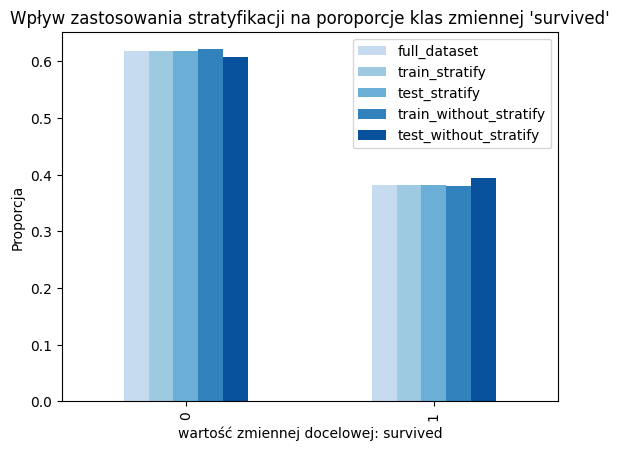

In [ ]:
data_plot = pd.DataFrame({
    "full_dataset": y.value_counts(normalize=True),
    "train_stratify": y_train.value_counts(normalize=True),
    "test_stratify": y_test.value_counts(normalize=True),
    "train_without_stratify": y_train2.value_counts(normalize=True),
    "test_without_stratify": y_test2.value_counts(normalize=True),
})
plt.figure(figsize=(10, 5))
colors = ["#c6dbef", "#9ecae1", "#6baed6", "#3182bd", "#08519c"]
data_plot.plot(kind="bar", color= colors)
plt.title("Wpływ zastosowania stratyfikacji na poroporcje klas zmiennej 'survived'")
plt.xlabel("wartość zmiennej docelowej: survived")
plt.ylabel("Proporcja")
plt.show()




Wnioski:

* Z użyciem parametru `stratify=y`:
  * treningowy zbiór ma wymiary 1047 x 2,
  * testowy zbiór ma wymiary 262 x 2,
  * proporcje klas w zbiorze treningowym i testowym są niemalże identyczne jak w całym zbiorze danych (`survived=0`: ok. 61.8%, `survived=1`: ok. 38.2%).
  * Ustawienie parametru stratify zapewniło reprezentatywny i spóljny podział zbiorów.

* Bez użycia parametru `stratify`:
  * wymiary zbiorów są identyczne jak przy stratyfikacji.
  * Występują niewielkie różnice w proporcjach klas pomiedzy zbiorem treningowym a testowym:
    * `survived 0`: 0.620821 (train) -> 0.60687 (test),
    * `survived 1`: 0.379179 (train) -> 0.39313 (test),
  * Przy większej liczbie klas lub bardziej niezbalansowanych danych brak stratyfikacji moze doprowadzic do niereprezentatywnnego testowania modelu.


<br><br>
* Powyższy wykres porwierdza, iż zastosowanie stratyfikacji skutkuje niemal idealnym odzorowaniem klas z całego zbioru w obu podzbiorach.

### 4. Sprawdzenie czy rozkład wartości w kolumnach jest podobny w obu zbiorach

In [ ]:
for col in col_name:
    print(f'\n{col}:')
    print('Train:')
    print(X_train[col].value_counts(normalize=True))
    print('Test:')
    print(X_test[col].value_counts(normalize=True))


CabinReduced:
Train:
CabinReduced
C    0.318584
B    0.234513
D    0.181416
E    0.128319
A    0.061947
F    0.057522
G    0.017699
Name: proportion, dtype: float64
Test:
CabinReduced
C    0.323529
B    0.176471
E    0.176471
A    0.117647
F    0.117647
D    0.073529
G    0.014706
Name: proportion, dtype: float64

sex:
Train:
sex
male      0.645654
female    0.354346
Name: proportion, dtype: float64
Test:
sex
male      0.637405
female    0.362595
Name: proportion, dtype: float64


**Wnioski:**<br>
Analiza rozkładu wartości w zbiorze treningowym i testowym wykazała, że rozkłady obu zmiennych `CabinReduced` oraz `sex` są spójne między podzbiorami danych:

**CabinReduced**:
* W obu zbiorach największy udział ma pokład C (ok. 31-32%),
* Największa różnica dotyczy pokładu **D**:
  * train: 18.1%
  * test: 7.4%,
* Proporcje pozostałych pokładów pomiędzy zbiorami różnią się nieznacznie,
* Różnice mogą wynikać z występowania braków danych ( jedynie 295 obserwacji ma przpisaną znaną wartość `CabinReduced` ).

**Sex**:
* Proporcje pomiędzy zbiorami są bardzo zbliżone (są stabilne):
    * male: 64.6% (train) -> 63.7% (test),
    * female: 35.4% (train) -> 36.3% (test),
* Rozkład jest niemal identyczny między zbiorami.


<br>
Badane zmienne kategoryczne zatem zachowują spójność rozkładów pomiędzy zbiorem treningowym a testowym.


### 5. Kodowanie zmiennych kategorycznych przy użyciu `labelEncoder`.

In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in col_name:
    encoder.fit(X_train[col].astype(str))
    X_train[col + '_map'] = encoder.transform(X_train[col].astype(str))
    X_test[col + '_map'] = encoder.transform(X_test[col].astype(str))

    code_table = X_train[[col, col+'_map']].drop_duplicates().sort_values(by=col + '_map', na_position='first')
    print(f'\n{col}:')
    print(code_table.to_string(index=False))



CabinReduced:
CabinReduced  CabinReduced_map
           A                 0
           B                 1
           C                 2
           D                 3
           E                 4
           F                 5
           G                 6
         NaN                 7

sex:
   sex  sex_map
female        0
  male        1


**Wnioski:**<br>
Użycie funkcji LabelEncoder() umożliwiło zakodowanie liczbowo wartości kategorii dla zmiennych `CabinReduced` oraz `sex`. Dla każdej unikalnej wartości w obrębie kolumny, została przypisana liczba całkowita zgodnie z kolejnością jej występowania. Brakujące wartości w przypadku `CabinReduced` również zostały zakodowane jako osobna kategoria i otrzymała kod = 7 (może być błędnie interpretowane przez model jako wartość porządkowa, nadając wartości NaN wyższą wagę od pozostałych kategorii).

Problematyczna była kolumna `Cabin`, która ze wzgledu na wysoką kartynalność utrudniała kodowanie, a także niosła ryzyko overfittingu. Dlatego zostałą ona wykluczona w punkcie 2 tego projektu.

### 6. Sprawdzenie i uzupełnienie brakujących wartości wypełniając ich braki zerami za pomocą funkcji `fillna()`.

In [ ]:
print(X_train.isna().sum())
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

CabinReduced        821
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64


**Wnioski:**<br>
Braki danych występowały jawnie jedynie w kolumnie `CabinReduced` (821 obserwacji). Odpowiadająca jej zakodowana kolumna `CabinReduced_map` nie zaiwerała braków, ponieważ brakujace wartosci `NaN` zostały przekształcone na tekst "nan" przed kodowaniem, a nastepnie przypisano im unikalny kod przez LabelEncoder.

### 7. Inne metody imputacji brakujących wartości.

W celu porównania różnych metod imutacji braków danych, należało cofnąć się do etapu sprzed kodowania zmiennych kategorycznych w 5 punkcie, ponieważ w 5 punkcie braki danych zostały zaklasyfikowane najpierw jako string a następnie zakodowane jako kod 7 w przypadku `CabinReduced_map`. Pozwoliło to przeprowadzić imputacje bez zakłócania sruktury orginalnych danych, a następnie zaobserwować różnice pomiedzy metodami.
#### 7.1 metoda `fillna('brak danych') `


In [ ]:
X_train_fillna = X_train_raw.copy()
X_test_fillna = X_test_raw.copy()
print("braki w train przed imputacja: \n", X_train_fillna.isna().sum())
print("braki w test przed imputacja: \n", X_test_fillna.isna().sum())
X_train_fillna['CabinReduced'] = X_train_fillna['CabinReduced'].fillna('brak danych')
X_test_fillna['CabinReduced'] = X_test_fillna['CabinReduced'].fillna('brak danych')
print("Train po imputacji:\n", X_train_fillna["CabinReduced"].value_counts(dropna=False))
print("Test po imputacji:\n",X_test_fillna["CabinReduced"].value_counts(dropna=False))

braki w train przed imputacja: 
 CabinReduced        821
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
braki w test przed imputacja: 
 CabinReduced        194
sex                   0
CabinReduced_map      0
sex_map               0
dtype: int64
Train po imputacji:
 CabinReduced
brak danych    821
C               72
B               53
D               41
E               29
A               14
F               13
G                4
Name: count, dtype: int64
Test po imputacji:
 CabinReduced
brak danych    194
C               22
B               12
E               12
A                8
F                8
D                5
G                1
Name: count, dtype: int64


Metoda `fillna('brak danych')` jest odpowiednia dla zmiennych kategorycznych, ponieważ brak danych zostaje jednoznacznie oznaczony jako osobna kateogoria. W tym przypadku braki danych w kolumnie `CabinReduced` zastąpiono wartością tekstową 'brak danych'. Liczba utworzonych Wartości 'brak danych' jest tożsama liczbie braków `NaN` w danych wejściowych.

#### 7.2 metoda `SimpleImputer(strategy='most_frequent')`

In [ ]:
from sklearn.impute import SimpleImputer

imp_mfreq = SimpleImputer(strategy='most_frequent')
X_train_mfreq = X_train_raw.copy()
X_test_mfreq = X_test_raw.copy()

X_train_mfreq['CabinReduced'] = imp_mfreq.fit_transform(X_train_raw[['CabinReduced']])[:, 0]
X_test_mfreq['CabinReduced'] = imp_mfreq.transform(X_test_raw[['CabinReduced']])[:, 0]

print("Train (most frequent):")
print(X_train_mfreq['CabinReduced'].value_counts(dropna=False))

print("\nTest (most frequent):")
print(X_test_mfreq['CabinReduced'].value_counts(dropna=False))



Train (most frequent):
CabinReduced
C    893
B     53
D     41
E     29
A     14
F     13
G      4
Name: count, dtype: int64

Test (most frequent):
CabinReduced
C    216
B     12
E     12
A      8
F      8
D      5
G      1
Name: count, dtype: int64


Metoda `SimpleImputer(strategy='most_frequent')` wypełnia brakujace wartosci wartością najczęściej występującą w kolumnie. W tym przypadku dla kolumny `CabinReduced` w obu przypadkach najliczniejsza była kategoria `C`, która po imputacji w zbiorze treningowym zwiększyła swoją liczebośc z 72 do **893** obserwacji stanowiąc około 85.3% danych trenignowych. W zbiorze testowym liczba wystąpień pokładu `C` wzrosła od 22 do **216** obserwacji, co odpowiada 82.4% danych testowych.

Imputacja ta prowadzi do zaburzenia orginalnego rozkładu klas, ponieważ znaczna liczba braków danych została zaklasyfikowaana do jednej z obecnych klas, znacznie zwiększając jej udział w zbiorze. Może to doprowadzić do uprzywilejowania pokładu C w analizach i modelowaniu.
<br><br><br>
Wykorzystanie innych zaproponowanych metod takich jak `SimpleImputer(strategy='median')`, `KNNImputer` czy `IterativeImputer` zostało odrzucone ponnieważ:

* `SimpleImputer(strategy='median')`: nie można stosować mediany do zmiennych kategorycznych  - metoda ta działa dla zmiennych liczbowych ciągłych.
*  `KNNImputer` i `IterativeImputer`: metody działają poprawnie na danych liczbowych, moglibyśmy zakodować nasze zmienne kategoryczne, ale kodowanie nie odzwierciedla rzezcywistych zależności miedzy klasami, co może doprowadzic do błędnej imputacji.

### 8. Porównanie liczby unikalnych wartości przed i po kodowaniem.

In [ ]:
for col in col_name:
    original_unique = X_train[col].nunique(dropna=False)
    encoded_unique = X_train[col + '_map'].nunique(dropna=False)
    print(f"{col}: {original_unique} unikalnych wartości -> {col + '_map'}: {encoded_unique} unikalnych wartości")


CabinReduced: 8 unikalnych wartości -> CabinReduced_map: 8 unikalnych wartości
sex: 2 unikalnych wartości -> sex_map: 2 unikalnych wartości


Liczba unikalnych wartości zakodowanych zmiennych (*_map) odpowiada liczbie unikalnych kategorii w danmych orginalnych przed kodowaniem (wliczając w to także braki danych `NaN`, które jak ustaliliśmy wcześniej są to braki typu MNAR -  a więc same w sobie są informacją). Proces kodowania `LabelEncoder()` nie zmniejszył liczby klas, a jedynie "przetłumaczył" je na wartości liczbowe.

### 9. Wnioski z labolatorium.

* Reprezentatywność zbiorów treningowego i testowego:
  * użycie stratyfikacji (parametr `stratify=y` w funkcji `train_test_split()`) poprawia jakośc podziału danych, to znaczy dzięki jego zastosowaniu uzyskano bardzo zbliżone proporcje klas zarówno w zbiorze treningowym, jak i testowym.
  * Dzięki stratyfikacji, podział danych zachował te same proporcje co orginalny zbiór - co potwierdza wykres.
  * Analiza zmiennych `CabinReduced` oraz `sex` wykazała, że te cechy również są spójne pomiedzy zbiorem treningowym a testowym (wyjatek stanowi pokład D).
  * Dzięki użyciu stratyfikacji uzyskaliśmy reprezentatrywne zbiory treningowe i testowe, a model nauczony na takim podziale ma większą sznasę na poprawną generalizację.


* Wpływ imputacji braków i kodowania:
  * Prosta metoda imputacji `fillna(0)` polega na zastępowaniu baków wartością zero, zastosowana na danych uprzednio zakodowanych liczbowo. Metoda ta niesie ryzyko błędnej interpretacji - wartość 0 może być potraktowana przez model jako niższy porządek kategorii. Dodadkowo nie daje informacji o tym, że pierwodtnie występował brak danych.
  * imputacja `fillna('brak danych')` - wypełnienie braków jednoznaczną, czytelną etykietą. Bezpieczne, informacyjne podejscie - pozwala zachować informacje o tym gdzie występowały btaki bez zakłócania rozkładu istniejących i poprawnie zakodowanych kals. Braki stają się osobną kategorią, co umożliwia modelowi wykorzystanie jako istotnej cechy. Liczba zastąpień jest równa liczbie pierwotnych braków.
  * `SimpleImputer(strategy='most_frequent')` - imputacja wartością najcześciej występującą ( w tym przypadku `C` ). Skutecznie eliminuje braki, ale powoduje silne zaburzenie rozkładu - udział pokładu `C` znacząco urósł w obu zbiorach. Takie przeszacowanie jednej klasy moze prowadzić do przewagi tej klasy w modeli i zafałszowania struktury danych.

  * Zmienne kategoryczne zakodowano przy użyciu `LabelEncoder()`, przypisując liczby całkowite kolejnym kategoriom, w tym także brakującym danym `NaN`, które otrzymały osobny kod. Kodowanie nie zmieniło liczby unikalnych wartości, każda kategoria została zachowana. Należy jednak pamiętać, że LabelEncoder wprowadza porządek liczbowy, który może być mylący dla modeli zakładających relacje numeryczne.

* Znaczenie stratyfikacji przy podziale danych:
  * Stratyfikacja zapewnia, że proporcje klas zmiennej docelowej (survived) są zachowane w zbiorze treningowym i testowym. Dzięki temu obie próbki lepiej reprezentują całą populację, co zmniejsza ryzyko błędnej oceny modelu. Bez stratyfikacji mogą wystąpić nierówne proporcje klas, co prowadzi do niereprezentatywnych wyników, zwłaszcza przy niezbalansowanych danych.

## **Inżynieria cech - ML Pipline** - Labolatorium 20.11.2025
      
---
`opracowanie: Kajetan Kowalski 421071`
### 1. Wczytanie danych i podział na zbiory treningowy i testowy z uwzględnieniem rozłożenia klas

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=421071, stratify=y
)
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(1047, 2) (262, 2)
survived
0    0.617956
1    0.382044
Name: proportion, dtype: float64
survived
0    0.618321
1    0.381679
Name: proportion, dtype: float64


### 2. Przygotowanie Pipeline dla zmienych kategorycznych, aby automatycznie uzupełniać brakujące wartości `SimpleImputer` oraz zamieniać kategorie na zmienne liczbowe `OneHotEncoder`.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
cat_features = ['CabinReduced', 'sex']
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('encoder', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_features)
    ]
)

#### Objaśnienie

* Parametr `handle_unknown='ignore'` sprawia, że jeżeli do zbioru testowego trafi
etykieta, której nie było w zbiorze trenigowym to `OneHotEncoder` zignoruje tę wartość nierzucając błędu, dzięki temu pipeline nie przerwie się i będzie działać stabilnie.

* Warto użyć `ColumnTransformer` zamiast `Pipeline` dla każdej kolumny osobno, ponieważ `ColumnTransformer` umożliwia obsłużyć wiele kolumn naraz, dzięki czemu kod jest mniej złożony i co za tym idzie barzdziej czytelny.
`ColumnTransformer` pozwala także dodać inne typy koluimn i przetwarzać je inaczej, co daje nam rozszerzalność i modularność kodu.

* `OneHotEncoder` nie razdzi sobie z obsługą braków danych `NaN`, aczkolwiek w tym przypadku braki danych zostały już uzupełnione poprzez `SimpleImputer()`. Zatem OneHotEncoder poradzi sobie, ponieważ pracujemy tylko ze zmiennymi kategorycznymi o małej liczbie etykiet:
  * 2 unikalne kategorie `sex`
  * 7 kolumn `CabinReduced`   

* `OneHotEncoder` unika narzucania porządku między kategoriami, co jest istotne w przypadku zmiennych nominalnych, takich jak CabinReduced i sex, ponieważ zapobiega błędnej interpretacji relacji między nimi przez model.



### 3. Tworzenie modelu

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=421071))
])

### 4. Trenowanie modelu i test pipeline

In [ ]:
model.fit(X_train, y_train)
acc = model.score(X_test, y_test)
print(f'Dokładność: {acc:.3f}')

Dokładność: 0.779


### 5. Weryfikacja przetworzonych danych

In [ ]:
from sklearn import set_config
set_config(display='diagram')  # pokazuje schemat pipeline
model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['CabinReduced', 'sex'])])),
                ('clf', RandomForestClassifier(random_state=421071))])

### 6. Dodatklowe zadania

* Sprawdź, czy liczba braków została poprawnie uzupełniona.

In [ ]:
test_nan = preprocessor.transform(X_train)
print("Czy są braki po przetwarzaniu?", np.isnan(test_nan.toarray()).any())

Czy są braki po przetwarzaniu? False


Tak, braki w Kolumnie `CabinReduced` zostału uzupełnione najczęściej występującą wartością (`C`) więc pozbyliśmy się wszystkich braków występujących w danych.
<br><br>

* Czy liczba nowych kolumn po `OneHotEncoder` jest zgodna z oczekiwaniami? Czy OneHotEncoder był wystarczający?

In [ ]:
encoded_cols = preprocessor.named_transformers_['cat'].named_steps['encoder']\
.get_feature_names_out(cat_features)
print("Zakodowane kolumny:")
print(encoded_cols)
print("Liczba kolumn po zakodowaniu:", len(encoded_cols))


Zakodowane kolumny:
['CabinReduced_A' 'CabinReduced_B' 'CabinReduced_C' 'CabinReduced_D'
 'CabinReduced_E' 'CabinReduced_F' 'CabinReduced_G' 'sex_female'
 'sex_male']
Liczba kolumn po zakodowaniu: 9


Tak, liczba kolumn po kodowaniu jest zgodna z założeniami ponieważ `SimpleImputer` usunął brakujące wartości w `CabinReduced`, dzięki czemu powstało 7 kategorii, natomiast zmienna `sex` miała 2 unikalne kategorie. W efekcie `OneHotEncoder` utworzył łącznie 9 kolumn, co potwierdza poprawne działanie pipeline.

W przypadku rozpatrywania całego zbioru Titanic `OneHotEncoder` jest wystarczający jedynie dla zmiennych kategorycznych o niskiej kardynalności, takie jak `CabinReduced`, `sex`, `pclass` czy `embarked`. Natomiast w przypadku kolumn o bardzo dużej ilości unikalnych wartości (wysokiej kardynalności) jak np. `name`, `ticket`, ta metoda kodowania nie znajdzie zastosowania. Użycie tej metody doprowadziło by do powstania tysięcy nowych zmiennych i stworzyłoby ryzyko przeuczenia modelu.

Metody obejścia:
* redukcja kardynalności zmiennych,
* grupowanie rzadkich kategorii do klasy "inne",
* kodowanie alternatywne,
* użycie frequency encoding,
* usunięcie kolumn o niskiej wartości analitycznej.
<br><br>

* Co by się stało, gdyby w zbiorze testowym pojawiła się nowa kategoria? Pojawiła się w tym przypadku?

In [ ]:
X_test = pd.DataFrame({
    'CabinReduced': ['NOWA'],
    'sex': ['male']
})
try:
  print(preprocessor.transform(X_test).toarray())
except Exception as e:
  print("BŁĄD: ", e)

[[0. 0. 0. 0. 0. 0. 0. 0. 1.]]


W przypadku pojawienia się nowej kategorii w danych testowych, `OneHotEncoder` nie zgłasza błędu (dzięki `handle_unknown='ignore'`), lecz przypisuje jej wektor zerowy. W naszym przykładzie testowym taka sytuacja wystąpiła — nowa kategoria `'NOWA'` w CabinReduced została zakodowana poprawnie jako wektor zer. W badanych danych Titanic taki problem nie wystąpił.